# GAN with Conv2D Layers for MNIST '0'

In [7]:
"""
Convolutional GAN on MNIST (Digit '0' Only)
-------------------------------------------

This notebook builds a GAN using Conv2D and Conv2DTranspose layers to generate images of the digit '0'.

It uses:
- Generator: Dense + Conv2DTranspose + BatchNorm + ReLU
- Discriminator: Conv2D + LeakyReLU
- Binary cross-entropy loss

Visual inspection of results is used to verify success.
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, LeakyReLU, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [8]:
# Load MNIST and filter for zeros
(X_train, y_train), (_, _) = mnist.load_data()
only_zeros = X_train[y_train == 0]
only_zeros = only_zeros / 255.0
only_zeros = np.expand_dims(only_zeros, axis=-1)

In [9]:
# Define the Generator model step-by-step using Conv2DTranspose
generator = Sequential()

# Input noise vector (latent space)
generator.add(Input(shape=(100,)))

# Dense layer to project and reshape into a 7x7x128 tensor
generator.add(Dense(7 * 7 * 128))
generator.add(Reshape((7, 7, 128)))
generator.add(BatchNormalization())

# First upsampling with Conv2DTranspose: 7x7 → 14x14
generator.add(Conv2DTranspose(
    filters=64,
    kernel_size=3,
    strides=2,
    padding='same',
    activation='relu'
))
generator.add(BatchNormalization())

# Second upsampling: 14x14 → 28x28 with 1 channel output
generator.add(Conv2DTranspose(
    filters=1,
    kernel_size=3,
    strides=2,
    padding='same',
    activation='sigmoid'  # Use sigmoid for pixel values between 0 and 1
))


I0000 00:00:1746254415.801771 1017823 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1086 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
# Define the Discriminator model with Conv2D layers
discriminator = Sequential()
discriminator.add(Input(shape=(28, 28, 1)))  # Explicit input layer for grayscale image

discriminator.add(Conv2D(64, kernel_size=3, strides=2, padding='same'))  # First Conv layer
discriminator.add(LeakyReLU(0.2))

discriminator.add(Conv2D(128, kernel_size=3, strides=2, padding='same'))  # Second Conv layer
discriminator.add(LeakyReLU(0.2))

discriminator.add(Flatten())  # Flatten the feature map
discriminator.add(Dense(1, activation='sigmoid'))  # Output layer (real/fake probability)

# Compile the model
discriminator.compile(
    loss='binary_crossentropy',
    optimizer='adam'
)



In [11]:
# GAN model
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer='adam')

In [12]:
# Training loop
batch_size = 32
codings_size = 100
dataset = (
    tf.data.Dataset.from_tensor_slices(only_zeros)
    .shuffle(1000)
    .batch(batch_size, drop_remainder=True)
    .prefetch(1)
)

for epoch in range(20):
    print(f"Epoch {epoch+1}/20")
    for real_images in dataset:
        # Train discriminator
        noise = tf.random.normal([batch_size, codings_size])
        fake_images = generator(noise)
        combined_images = tf.concat([fake_images, tf.cast(real_images, tf.float32)], axis=0)
        labels = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)

        discriminator.trainable = True
        discriminator.train_on_batch(combined_images, labels)

        # Train generator
        noise = tf.random.normal([batch_size, codings_size])
        misleading_labels = tf.constant([[1.]] * batch_size)

        discriminator.trainable = False
        gan.train_on_batch(noise, misleading_labels)

Epoch 1/20


I0000 00:00:1746254416.388345 1017823 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1746254416.780812 1017823 service.cc:152] XLA service 0x3093eaa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746254416.780822 1017823 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-05-02 23:40:16.790209: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746254417.281797 1017823 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-05-02 23:40:19.274515: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2/20


2025-05-02 23:40:20.099321: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 3/20
Epoch 4/20


...

Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20


2025-05-02 23:40:25.140562: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20


2025-05-02 23:40:32.051084: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20


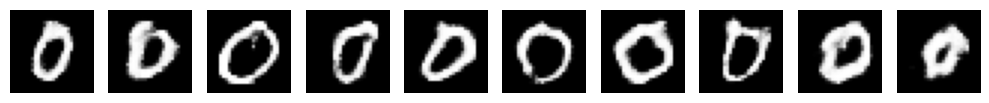

In [13]:
# Generate and plot samples
noise = tf.random.normal([10, 100])
samples = generator(noise)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(samples[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()